In [25]:
import sys
import pandas as pd
import numpy as np
import scipy.sparse as sparse
from scipy.sparse.linalg import spsolve
import random
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import implicit
import pickle

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Data Loading and Preprocessing

In [2]:
np.random.seed(44)
random.seed(44)

df = pd.read_csv('dataset/OnlineRetail.csv')

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-10 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-10 8:34,1.69,13047.0,United Kingdom


In [5]:
print("Dataset Information")
print("=" * 50)
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Data Cleaning

In [6]:
df = df[df['CustomerID'].notna()]

print(f"Rows after removing null CustomerIDs: {len(df)}")
print(f"Unique customers: {df['CustomerID'].nunique()}")

Rows after removing null CustomerIDs: 406829
Unique customers: 4372


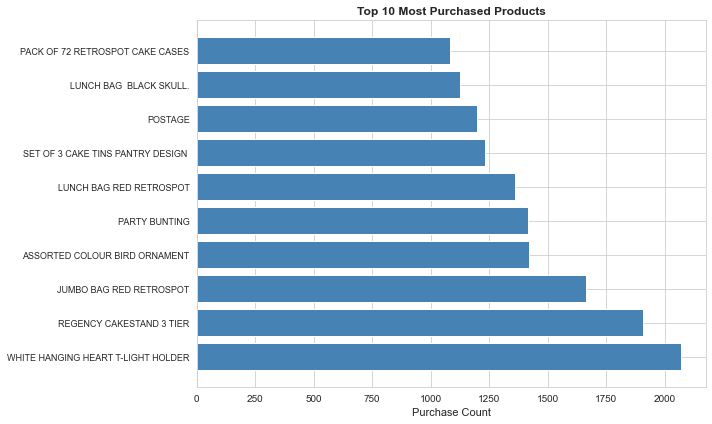

In [7]:
top_items = df['Description'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top_items)), top_items.values, color='steelblue')
plt.yticks(range(len(top_items)), top_items.index, fontsize=9)
plt.xlabel("Purchase Count", fontsize=11)
plt.title("Top 10 Most Purchased Products", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Aggregation

In [8]:
grouped = df[['CustomerID', 'StockCode', 'Description', 'Quantity']].groupby(
    ['CustomerID', 'StockCode', 'Description']).sum().reset_index()
grouped.loc[grouped['Quantity'] == 0, 'Quantity'] = 1
grouped = grouped[grouped['Quantity'] > 0]

print(f"Unique customers: {grouped.CustomerID.nunique()}")
print(f"Unique items: {grouped.StockCode.nunique()}")
print(f"Average quantity per transaction: {grouped.Quantity.mean():.2f}")

Unique customers: 4338
Unique items: 3664
Average quantity per transaction: 18.37


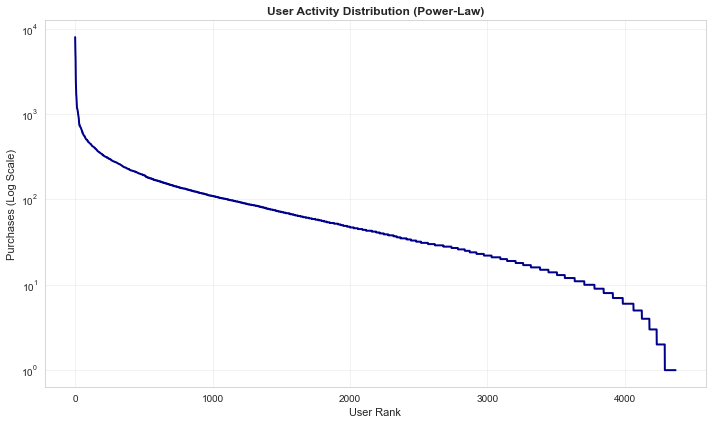

In [9]:
user_activity = df.groupby('CustomerID')['StockCode'].count()
sorted_activity = np.sort(user_activity)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(sorted_activity, linewidth=2, color='darkblue')
plt.yscale('log')
plt.xlabel("User Rank", fontsize=11)
plt.ylabel("Purchases (Log Scale)", fontsize=11)
plt.title("User Activity Distribution (Power-Law)", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sparse Matrix Representation

In [10]:
unique_customers = grouped.CustomerID.unique()
customer_ids = dict(zip(unique_customers, np.arange(len(unique_customers), dtype=np.int32)))

unique_items = grouped.StockCode.unique()
item_ids = dict(zip(unique_items, np.arange(len(unique_items), dtype=np.int32)))

grouped['customer_id'] = grouped.CustomerID.map(customer_ids)
grouped['item_id'] = grouped.StockCode.map(item_ids)

In [11]:
sparse_item_user = sparse.csr_matrix(
    (grouped['Quantity'].astype(float), (grouped['item_id'], grouped['customer_id']))
)
sparse_user_item = sparse.csr_matrix(
    (grouped['Quantity'].astype(float), (grouped['customer_id'], grouped['item_id']))
)

print(f"User-Item matrix shape: {sparse_user_item.shape}")
print(f"Sparsity: {1 - sparse_user_item.nnz / (sparse_user_item.shape[0] * sparse_user_item.shape[1]):.4f}")

User-Item matrix shape: (4338, 3664)
Sparsity: 0.9832


## Model Training with ALS

In [12]:
model = implicit.als.AlternatingLeastSquares(
    factors=20, regularization=0.1, iterations=50, random_state=44
)

alpha = 15
data = (sparse_item_user * alpha).astype('double')

print("Training ALS model...")
model.fit(data)
print("Training complete!")

Training ALS model...


C:\Users\altha\AppData\Local\Programs\Python\Python310\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/50 [00:00<?, ?it/s]

Training complete!


In [13]:
def find_similar_items(item_id, n_similar=10):
    item_vecs = model.item_factors
    item_norms = np.sqrt((item_vecs * item_vecs).sum(axis=1))
    
    scores = item_vecs.dot(item_vecs[item_id]) / item_norms
    top_idx = np.argpartition(scores, -n_similar)[-n_similar:]
    similar = sorted(zip(top_idx, scores[top_idx] / item_norms[item_id]), key=lambda x: -x[1])
    
    return similar

item_id = 1319
similar_items = find_similar_items(item_id, n_similar=10)

item_name = grouped[grouped['item_id'] == item_id]['Description'].iloc[0]
print(f"Items similar to: {item_name}\n")
for idx, score in similar_items:
    description = grouped[grouped['item_id'] == idx]['Description'].iloc[0]
    print(f"{description} (score: {score:.3f})")

Items similar to: WHITE METAL LANTERN

WHITE METAL LANTERN (score: 1.000)
FLAG OF ST GEORGE CHAIR (score: 0.755)
MULTICOLOUR HONEYCOMB FAN (score: 0.680)
HEART MINI PORTRAIT FRAME (score: 0.676)
ROTATING SILVER ANGELS T-LIGHT HLDR (score: 0.637)
LANTERN CREAM GAZEBO  (score: 0.632)
LARGE CAMPHOR WOOD FIELD MUSHROOM  (score: 0.630)
BLUE ROUND COMPACT MIRROR (score: 0.621)
VINTAGE CHRISTMAS PAPER GIFT BAG (score: 0.615)
GOLD M PEARL  ORBIT NECKLACE (score: 0.614)


In [26]:
# Saving the model for later use
from recommendation_api import create_api_from_notebook_data
api = create_api_from_notebook_data(model, grouped, sparse_user_item, customer_ids, item_ids)
api.save_model('models/als_model.pkl')
api.save_data('models/dataset.pkl')

Model saved to models/als_model.pkl
Data saved to models/dataset.pkl


## Item Recommendations

In [14]:
def get_recommendations(customer_id, n_items=10):
    customer_interactions = sparse_user_item[customer_id, :].toarray().reshape(-1) + 1
    customer_interactions[customer_interactions > 1] = 0
    
    customer_vecs = sparse.csr_matrix(model.user_factors)
    item_vecs = sparse.csr_matrix(model.item_factors)
    
    rec_vector = customer_vecs[customer_id, :].dot(item_vecs.T).toarray()
    
    scaler = MinMaxScaler()
    rec_vector_scaled = scaler.fit_transform(rec_vector.reshape(-1, 1))[:, 0]
    
    if customer_interactions.shape != rec_vector_scaled.shape:
        min_len = min(len(customer_interactions), len(rec_vector_scaled))
        customer_interactions = customer_interactions[:min_len]
        rec_vector_scaled = rec_vector_scaled[:min_len]
    
    recommendation_scores = customer_interactions * rec_vector_scaled
    item_indices = np.argsort(recommendation_scores)[::-1][:n_items]
    
    recommendations = []
    for idx in item_indices:
        desc = grouped[grouped['item_id'] == idx]['Description'].iloc[0]
        recommendations.append({'Item': desc, 'Score': recommendation_scores[idx]})
    
    return pd.DataFrame(recommendations)

In [15]:
customer_id = 2
recommendations = get_recommendations(customer_id, n_items=10)

print(f"\nTop 10 Recommendations for Customer {customer_id}:\n")
print(recommendations.to_string(index=False))


Top 10 Recommendations for Customer 2:

                         Item    Score
PURPLE GLASS TASSLE BAG CHARM 1.000000
    JUMBO BAG 50'S CHRISTMAS  0.913689
BANK ACCOUNT  GREETING  CARD  0.912556
 GREEN PAIR HEART HAIR SLIDES 0.898670
FRENCH PAISLEY CUSHION COVER  0.891069
CARDHOLDER HOLLY WREATH METAL 0.884024
          CLASSIC WHITE FRAME 0.879374
     VINTAGE BEAD PINK PURSE  0.870892
      RETRO PLASTIC 70'S TRAY 0.860894
    SCANDINAVIAN REDS RIBBONS 0.850739


In [16]:
print(f"\nCustomer {customer_id} Purchase History (Top 10):\n")
history = grouped[grouped['customer_id'] == customer_id].sort_values('Quantity', ascending=False)
print(history[['Description', 'Quantity']].head(10).to_string(index=False))


Customer 2 Purchase History (Top 10):

                      Description  Quantity
              DOUGHNUT LIP GLOSS        200
         ICE CREAM PEN LIP GLOSS        192
PACK OF 12 HEARTS DESIGN TISSUES        144
         PACK OF 12 SUKI TISSUES        144
  60 CAKE CASES VINTAGE CHRISTMAS       144
      PACK OF 72 SKULL CAKE CASES       144
 PACK OF 12 BLUE PAISLEY TISSUES        144
      60 TEATIME FAIRY CAKE CASES       144
     PACK OF 12 WOODLAND TISSUES        144
PACK OF 12 RED RETROSPOT TISSUES        144


## Model Evaluation

In [17]:
def train_test_split(ratings, test_pct=0.2):
    test_set = ratings.copy()
    test_set[test_set != 0] = 1
    
    training_set = ratings.copy()
    nonzero_inds = training_set.nonzero()
    nonzero_pairs = list(zip(nonzero_inds[0], nonzero_inds[1]))
    
    random.seed(0)
    num_samples = int(np.ceil(test_pct * len(nonzero_pairs)))
    samples = random.sample(nonzero_pairs, num_samples)
    
    item_inds = [idx[0] for idx in samples]
    customer_inds = [idx[1] for idx in samples]
    
    training_set[item_inds, customer_inds] = 0
    training_set.eliminate_zeros()
    
    return training_set, test_set, list(set(customer_inds))

item_train, item_test, altered_customers = train_test_split(sparse_item_user, test_pct=0.2)
print(f"Split data: {len(altered_customers)} customers in test set")

Split data: 4063 customers in test set


In [18]:
def compute_auc(predictions, actual):
    if len(np.unique(actual)) < 2:
        return None
    fpr, tpr, _ = metrics.roc_curve(actual, predictions)
    return metrics.auc(fpr, tpr)

def evaluate_auc(training_set, test_customers, user_vecs, item_vecs, test_set):
    model_auc = []
    baseline_auc = []
    
    popularity = np.array(test_set.sum(axis=1)).reshape(-1)
    
    for cust in test_customers:
        training_col = training_set[:, cust].toarray().reshape(-1)
        unseen_items = np.where(training_col == 0)[0]
        
        user_vec = user_vecs[cust, :]
        predictions = user_vec.dot(item_vecs)
        
        pred_unseen = predictions[unseen_items]
        actual_unseen = test_set[:, cust].toarray()[unseen_items].reshape(-1)
        pop_unseen = popularity[unseen_items]
        
        auc1 = compute_auc(pred_unseen, actual_unseen)
        auc2 = compute_auc(pop_unseen, actual_unseen)
        
        if auc1 is not None:
            model_auc.append(auc1)
        if auc2 is not None:
            baseline_auc.append(auc2)
    
    return model_auc, baseline_auc

In [19]:
user_vecs = model.item_factors
item_vecs = model.user_factors

model_auc, baseline_auc = evaluate_auc(
    item_train, altered_customers, user_vecs, item_vecs.T, item_test
)

print("=" * 50)
print("AUC Evaluation Results")
print("=" * 50)
print(f"Model AUC (Mean):     {np.mean(model_auc):.4f}")
print(f"Baseline AUC (Mean):  {np.mean(baseline_auc):.4f}")
print(f"Improvement:          {(np.mean(model_auc) - np.mean(baseline_auc)):.4f}")
print("=" * 50)

AUC Evaluation Results
Model AUC (Mean):     0.9377
Baseline AUC (Mean):  0.8148
Improvement:          0.1229


In [20]:
def evaluate_metrics(training_set, test_customers, user_vecs, item_vecs, test_set, k_values=[1, 5, 10]):
    precisions = {k: [] for k in k_values}
    recalls = {k: [] for k in k_values}
    ndcgs = {k: [] for k in k_values}
    
    item_vecs_t = item_vecs.T
    
    for user in test_customers:
        training_col = training_set[:, user].toarray().reshape(-1)
        seen_items = np.where(training_col > 0)[0]
        
        user_vec = user_vecs[user, :]
        scores = user_vec.dot(item_vecs_t)
        scores[seen_items] = -np.inf
        
        ranked = np.argsort(-scores)
        
        test_item_idx = np.where(test_set[:, user].toarray().reshape(-1) > 0)[0]
        if len(test_item_idx) == 0:
            continue
        test_item = test_item_idx[0]
        
        for k in k_values:
            topk = ranked[:k]
            hit = 1.0 if test_item in topk else 0.0
            precisions[k].append(hit)
            recalls[k].append(hit)
            
            if test_item in topk:
                rank_pos = np.where(topk == test_item)[0][0]
                ndcgs[k].append(1.0 / np.log2(rank_pos + 2))
            else:
                ndcgs[k].append(0.0)
    
    return {
        "Precision@K": {k: np.mean(precisions[k]) for k in k_values},
        "Recall@K": {k: np.mean(recalls[k]) for k in k_values},
        "NDCG@K": {k: np.mean(ndcgs[k]) for k in k_values},
    }

In [21]:
k_list = [1, 5, 10]
results = evaluate_metrics(item_train, altered_customers, user_vecs, item_vecs, item_test, k_list)

In [22]:
results_df = pd.DataFrame(results)
print("\n" + "=" * 50)
print("Top-K Recommendation Metrics")
print("=" * 50)
print(results_df.round(4))


Top-K Recommendation Metrics
    Precision@K  Recall@K  NDCG@K
1        0.0059    0.0059  0.0059
5        0.0190    0.0190  0.0124
10       0.0271    0.0271  0.0150


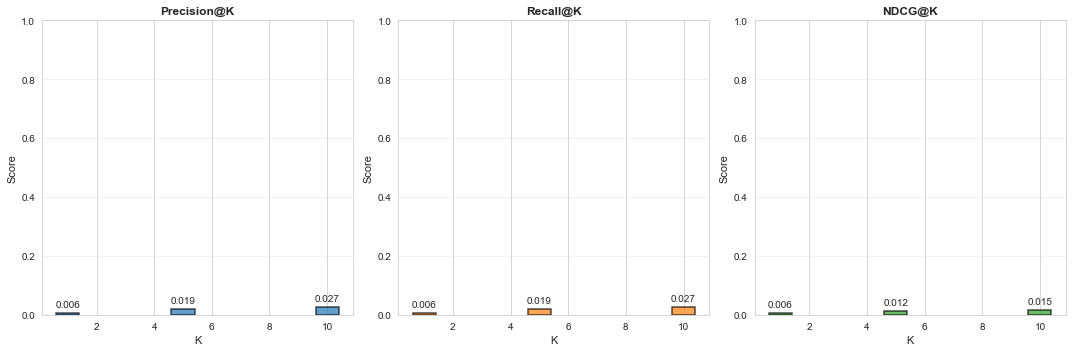

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_names = list(results.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics_names):
    ks = list(results[metric].keys())
    vals = list(results[metric].values())
    
    axes[idx].bar(ks, vals, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("K", fontsize=11)
    axes[idx].set_ylabel("Score", fontsize=11)
    axes[idx].set_ylim(0, 1)
    axes[idx].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(vals):
        axes[idx].text(ks[i], v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

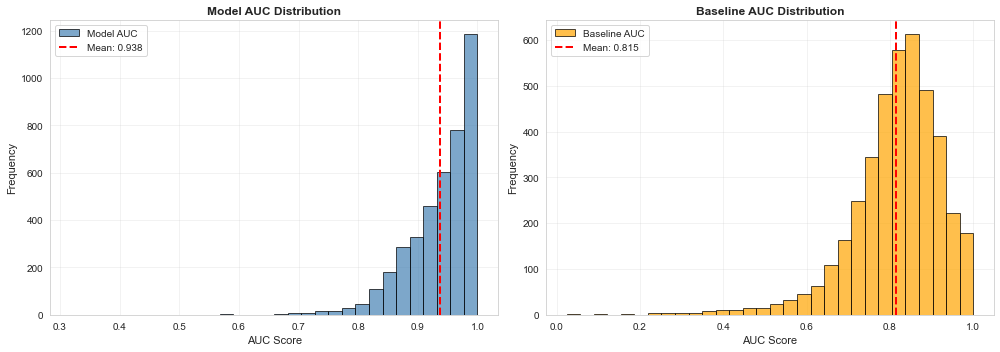

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(model_auc, bins=30, alpha=0.7, color='steelblue', edgecolor='black', label='Model AUC')
ax1.axvline(np.mean(model_auc), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(model_auc):.3f}')
ax1.set_xlabel('AUC Score', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Model AUC Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(baseline_auc, bins=30, alpha=0.7, color='orange', edgecolor='black', label='Baseline AUC')
ax2.axvline(np.mean(baseline_auc), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(baseline_auc):.3f}')
ax2.set_xlabel('AUC Score', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Baseline AUC Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()